# Importing Libraries

In [5]:
import numpy as np
from scipy import ndimage
from imageio import imread
import cv2
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Single Scale Template Matching (Week10 Lab Exercise Submission)

### Load template and apply necessary preprocessing

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Template's Shape:   (108, 81)


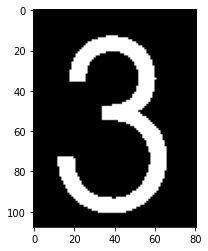

Template's Unique:  [  0 255]


In [6]:
template = imread('./W10LabData/template.png', pilmode='L')
# reverse the grayscale color
template = 255 -  template

# binarize pixels
template[template < 128] = 0
template[127 < template] = 255

print(template)

print(f"Template's Shape:   {template.shape}") # (row, col) OR (height, width) OR (108, 81)
plt.imshow(template, cmap='gray')
plt.show()

# print unique elements of template
print(f"Template's Unique:  {np.unique(template)}")


### Load input image and apply necessary preprocessing

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(1053, 745)
[  0 255]


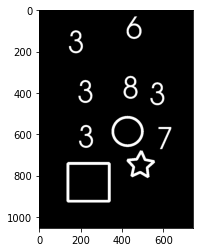

946 665


In [7]:
input_img = imread('./W10LabData/input.png', pilmode='L')
input_img[input_img < 128] = 0
input_img[127 < input_img] = 255
input_img = 255 - input_img

print(input_img)
print(input_img.shape)
print(np.unique(input_img))

plt.imshow(input_img, cmap='gray')
plt.show()

number_of_width = input_img.shape[0] - template.shape[0] + 1
number_of_col = input_img.shape[1] - template.shape[1] + 1
print(number_of_width, number_of_col)


## Get the SSD_Map

In [125]:
# ToDo: Complete your code here
# Please include your full name and unikey in your final image to be submitted
import math

def ssd(image, temp):
    """
    Calculate the ssd of part of the image and the template
    """
    ssd = 0
    for row in range(0, template.shape[0]):
        for col in range(0, template.shape[1]):
            img_pixel = image[row, col]
            temp_pixel = temp[row, col]
            ssd += math.pow((temp_pixel - img_pixel), 2)
    return ssd


# main block of code

# get the number of rows and columns of template
temp_row = template.shape[0]
temp_col = template.shape[1]

# generate ssd-Map by computing ssd values for all pixels in input image
number_of_width = input_img.shape[0] - temp_row + 1
number_of_col = input_img.shape[1] - temp_col + 1
ssd_map = np.zeros((number_of_width, number_of_col))

# get the ssd_map
for row in range(0, number_of_width):
    for col in range(0, number_of_col):

        print(f"\r({row}, {col}) out of ({number_of_width}, {number_of_col})", end="\r")
        
        # get the neighbors of the input image
        neighbors = input_img[row:row + temp_row, col:col + temp_col]

        # get the ssd
        current_ssd = ssd(neighbors, template)

        # add to the ssd_map
        ssd_map[row, col] = current_ssd

print(ssd_map)

KeyboardInterrupt: 

In [3]:
# save data to an external file
file = open("ssd_map", "w")
for row in range(0, ssd_map.shape[0]):
    for col in range(0, ssd_map.shape[1]):
        file.write(str(ssd_map[row, col]))
        file.write(" ")
    file.write("\n")

NameError: name 'ssd_map' is not defined

In [8]:
# reseting the ssd_map
ssd_map = np.zeros((number_of_width, number_of_col))
file = open("ssd_map2", "r")
data = file.readlines()
file.close()

for row in range(0, ssd_map.shape[0]):
    line = data[row].strip("\n").split(" ")
    for col in range(0, ssd_map.shape[1]):
        ssd_map[row, col] = np.float64(float(line[col]))

print(ssd_map)

[[98577900. 98577900. 98577900. ... 98577900. 98577900. 98577900.]
 [98577900. 98577900. 98577900. ... 98577900. 98577900. 98577900.]
 [98577900. 98577900. 98577900. ... 98577900. 98577900. 98577900.]
 ...
 [98577900. 98577900. 98577900. ... 98577900. 98577900. 98577900.]
 [98577900. 98577900. 98577900. ... 98577900. 98577900. 98577900.]
 [98577900. 98577900. 98577900. ... 98577900. 98577900. 98577900.]]


## Get the Target Coordinates

In [10]:
# the number of matching templates we want to find in the image
target_num = 5

# target result
target_res = []

# get the local min and local max
local_min = 0
local_max = 0

# get the number of rows and columns of template
temp_row = template.shape[0]
temp_col = template.shape[1]

# loop for targe_num times
i = 0
while (i < target_num):

    local_max = np.max(ssd_map)
    local_min = np.min(ssd_map)

    x, y = np.where(ssd_map == local_min)
    x, y = x[0], y[0]

    # # append the result's coordinate
    target_res.append((x, y))

    # set the max value
    for row in range(x-temp_row, x+temp_row):
        for col in range(y-temp_row, y+temp_col):
            if (row >= ssd_map.shape[0] or row < 0 or col >= ssd_map.shape[1] or col < 0):
                continue
            ssd_map[row, col] = local_max

    i += 1

print(target_res)

[(271, 403), (50, 139), (290, 185), (301, 533), (507, 188)]


## Create the final image

271 403
50 139
290 185
301 533
507 188


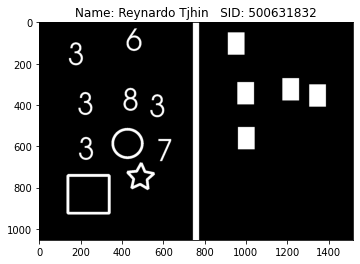

In [11]:
# get the final image
final_img = np.zeros((input_img.shape[0], input_img.shape[1]))

# assign white color to the highlighted ones in target result
for (x, y) in target_res:
    print(x, y)
    for row in range(0, template.shape[0]):
        for col in range(0, template.shape[1]):
            final_img[x+row, y+col] = 255

# show the final image
# plt.imshow(final_img, cmap='gray')
# plt.show()

separator = np.multiply(np.ones((input_img.shape[0], 30)), 255)
combined_img = np.concatenate((input_img, separator), 1)
combined_img = np.concatenate((combined_img, final_img), 1)
plt.imshow(combined_img, cmap='gray')
plt.title("Name: Reynardo Tjhin   SID: 500631832")
plt.show()

# Extension: Multi-scale Template Matching

(1053, 745)


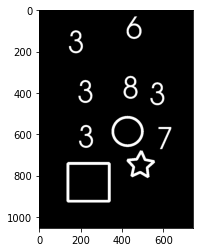

[  0 255]


In [29]:
input2 = imread('./W10LabData/input.png', pilmode='L')
input2[input2 < 128] = 0
input2[127 < input2] = 255
input2 = 255 - input2
print(input2.shape)
plt.imshow(input2, cmap='gray')
plt.show()
print(np.unique(input2))

In [30]:
# ToDo: Complete your code here

# Advanced Extension: Feature-based Template Matching

(1053, 745)


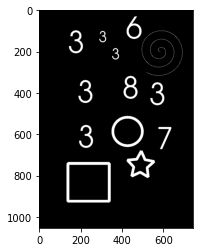

[  0 255]


In [31]:
input3 = imread('./W10LabData/input_feature_based_matching.png', pilmode='L')
input3[input3 < 128] = 0
input3[127 < input3] = 255
input3 = 255 - input3
print(input3.shape)
plt.imshow(input3, cmap='gray')
plt.show()
print(np.unique(input3))

In [32]:
# ToDo: Complete your code here